# Spectral classification of SDSS sources with GalSpecNet

Trains `astrospec.models.galspecnet.GalSpecNet`
([Wu et al. 2023, MNRAS 527:1163](https://doi.org/10.1093/mnras/stad2913)) to
separate the three SDSS pipeline classes, GALAXY, QSO and STAR, from optical
spectra alone.

The data is the [MultimodalUniverse](https://huggingface.co/MultimodalUniverse)
SDSS release. `utils/sdss.py` reads a local HDF5 copy when `ASTROSPEC_SDSS_ROOT`
points at one and streams
[`MultimodalUniverse/sdss`](https://huggingface.co/datasets/MultimodalUniverse/sdss)
otherwise. Only the local copy carries the `CLASS` column this notebook trains
on.

Two things about the setup. The labels are the SDSS pipeline's own
template-fit classification, not independent ground truth, so the model learns
to imitate that pipeline. And GalSpecNet is a fixed-grid model. Its head is a
flat MLP over the final convolutional activations, so every spectrum has to
arrive on the same wavelength grid. SDSS spectra do not. They share a log-lambda
pixel spacing but cover slightly different windows, so `utils.sdss` interpolates
them onto one common grid first. AstroSpec ships no
resampling of its own; that choice belongs to the dataset.

## Install example-only dependencies

Not part of AstroSpec's core install, only needed for this example.

In [1]:
!pip install -q h5py datasets scikit-learn matplotlib

## Imports

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import astrospec
from utils import sdss

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load a balanced subset

2,000 spectra per class. QSOs are the rarest of the three in SDSS, so a balanced
draw reads through more shards than an unbalanced one would; it keeps accuracy
interpretable without class weighting.

In [3]:
flux, labels = sdss.load_classes(n_per_class=2000)
flux = sdss.standardize(flux)
flux.shape, np.bincount(labels), sdss.CLASS_NAMES

((6000, 3841), array([2000, 2000, 2000]), ['GALAXY', 'QSO', 'STAR'])

## What the three classes look like

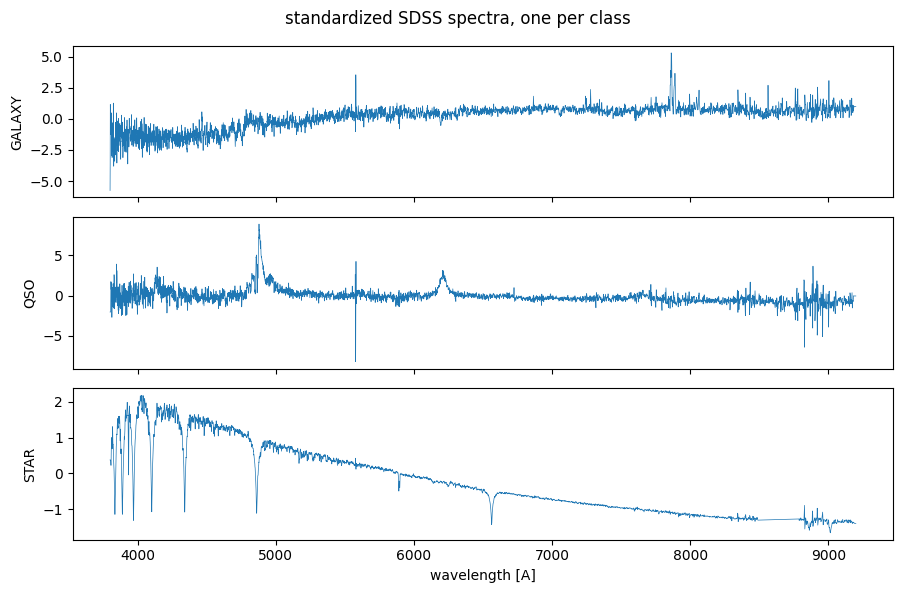

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for ax, name in zip(axes, sdss.CLASS_NAMES):
    i = int(np.flatnonzero(labels == sdss.CLASS_NAMES.index(name))[0])
    ax.plot(sdss.COMMON_GRID, flux[i], lw=0.5)
    ax.set_ylabel(name)
axes[-1].set_xlabel("wavelength [A]")
fig.suptitle("standardized SDSS spectra, one per class")
fig.tight_layout()

## Split 70/10/20

Stratified, so each split keeps the balance.

In [5]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(labels))
train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=labels, random_state=0)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.125, stratify=labels[train_idx], random_state=0
)

def loader(indices, shuffle):
    dataset = TensorDataset(
        torch.from_numpy(flux[indices]), torch.from_numpy(labels[indices])
    )
    return DataLoader(dataset, batch_size=64, shuffle=shuffle)

train_loader, val_loader, test_loader = (
    loader(train_idx, True), loader(val_idx, False), loader(test_idx, False)
)
len(train_idx), len(val_idx), len(test_idx)

(4200, 600, 1200)

## The model

Constructed through the registry; `astrospec.models.galspecnet.GalSpecNet` is
importable directly and takes the same arguments. `input_length` is the grid the
spectra were resampled onto, and the model consumes `flux` only, not
`wavelength`, `ivar`, `mask`, or `lsf_sigma`.

In [6]:
model = astrospec.create_model(
    "galspecnet", input_length=flux.shape[1], num_classes=len(sdss.CLASS_NAMES)
).to(device)
sum(p.numel() for p in model.parameters())

506627

## Train

In [7]:
EPOCHS = 20
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

def evaluate(data_loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in data_loader:
            pred = model(x.to(device)).argmax(-1).cpu()
            correct += (pred == y).sum().item()
            total += len(y)
    return correct / total

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for x, y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()
        running += loss.item() * len(y)
    print(
        f"epoch {epoch + 1:2d}  train loss {running / len(train_idx):.4f}"
        f"  val acc {evaluate(val_loader):.4f}"
    )

epoch  1  train loss 1.0050  val acc 0.6550


epoch  2  train loss 0.6782  val acc 0.8050


epoch  3  train loss 0.4699  val acc 0.8617


epoch  4  train loss 0.3698  val acc 0.8650


epoch  5  train loss 0.3355  val acc 0.8833


...

epoch 16  train loss 0.2130  val acc 0.9217


epoch 17  train loss 0.2038  val acc 0.9317


epoch 18  train loss 0.2051  val acc 0.9333


epoch 19  train loss 0.2007  val acc 0.9333


epoch 20  train loss 0.1923  val acc 0.9383


## Test accuracy and confusion matrix

              precision    recall  f1-score   support

      GALAXY      0.925     0.953     0.938       400
         QSO      0.908     0.912     0.910       400
        STAR      0.961     0.927     0.944       400

    accuracy                          0.931      1200
   macro avg      0.931     0.931     0.931      1200
weighted avg      0.931     0.931     0.931      1200



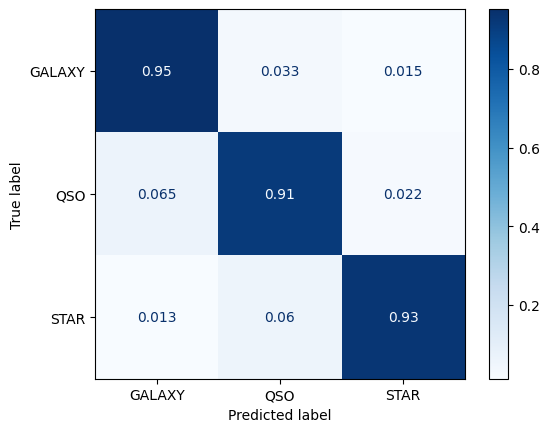

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

model.eval()
preds = []
with torch.no_grad():
    for x, _ in test_loader:
        preds.append(model(x.to(device)).argmax(-1).cpu())
preds = torch.cat(preds).numpy()

print(classification_report(labels[test_idx], preds, target_names=sdss.CLASS_NAMES, digits=3))
ConfusionMatrixDisplay.from_predictions(
    labels[test_idx], preds, display_labels=sdss.CLASS_NAMES, normalize="true", cmap="Blues"
)

## Notes

The paper trains on a larger SDSS DR16 sample and reports accuracies in the high
nineties; this is a tutorial-scale run on 6,000 spectra from one sub-survey, so
treat ~93% as a sanity check on the wiring, not a reproduction.

The residual errors concentrate on QSOs, which have the lowest per-class
precision and recall of the three. That is the expected failure mode here. A
fixed-grid CNN sees a spectrum at whatever redshift it was observed, so the
emission lines that identify a quasar sit at a different pixel for every object,
while a star's continuum shape and absorption features stay put. The library
carries models that take `wavelength` as an input, or that pretrain a
representation of the sequence before you attach a classifier, for exactly this
reason.